In [55]:
# mini_transformer
import os, re, json, math, random, time
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns


The model was trained on a 5,000-sample subset of the IMDb dataset using sequences of up to 200 tokens and a 20k-word vocabulary (min freq = 2). Training ran for 5 epochs with a batch size of 64 and a learning rate of 1e-3, ensuring reproducible results with seed 42.

In [56]:
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CSV_PATH   = "data/IMDB Dataset.csv"   
SUBSET     = 5000    # set to None for full 50k;
MAX_LEN    = 200     # sequence length
MIN_FREQ   = 2       # vocab minimum token frequency
MAX_VOCAB  = 20000   # top-k tokens to keep in vocab
BATCH_SIZE = 64
EPOCHS     = 5       
LR         = 1e-3

MODEL_PATH = "mini_transformer_imdb.pt"
VOCAB_PATH = "mini_transformer_imdb_vocab.json"

The script loads the IMDb dataset from the first valid CSV path found among local and project directories. It maps sentiment labels (“positive” → 1, “negative” → 0) and, if specified, randomly samples a smaller subset for faster training and testing

In [57]:

# Load dataset from CSV
candidates = [
    CSV_PATH,
    r"c:\Users\DSU Student\Desktop\702\transformers\IMDB Dataset.csv",
    os.path.join(os.getcwd(), "data", "IMDB Dataset.csv"),
]

CSV_PATH_FOUND = next((p for p in candidates if p and os.path.exists(p)), None)
if CSV_PATH_FOUND is None:
    raise FileNotFoundError(f"CSV not found. Looked for: {candidates}")

df = pd.read_csv(CSV_PATH_FOUND)
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1}).astype(int)

if SUBSET is not None:
    df = df.sample(n=SUBSET, random_state=SEED).reset_index(drop=True)


tokenizes each text string into lowercase words and numbers, using regular expressions to split on non-alphanumeric characters.

In [58]:
#  Tokenizer (simple & deterministic)

def basic_tokenize(text: str):
    return re.findall(r"[A-Za-z0-9']+", str(text).lower())

splits the IMDb dataset into training and testing subsets, using an 80/20 ratio while preserving the same proportion of positive and negative reviews through stratified sampling.

In [59]:
# 3) Train/test split

train_texts, test_texts, y_train, y_test = train_test_split(
    df["review"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"].tolist()
)

This block builds the vocabulary only from the training data to avoid data leakage. It counts token frequencies, keeps words appearing at least twice (up to 20,000 most common), and adds special tokens <pad> and <unk>. Each token is then mapped to a unique integer ID for model input encoding.

In [60]:
# Build vocabulary on TRAIN ONLY
counter = Counter()
for t in train_texts:
    counter.update(basic_tokenize(t))

PAD, UNK = "<pad>", "<unk>"
most_common = [w for w, c in counter.most_common() if c >= MIN_FREQ]
if MAX_VOCAB is not None:
    most_common = most_common[:MAX_VOCAB]

itos = [PAD, UNK] + most_common
stoi = {w:i for i,w in enumerate(itos)}
pad_idx, unk_idx = stoi[PAD], stoi[UNK]
vocab_size = len(itos)

def encode(tokens):
    return [stoi.get(tok, unk_idx) for tok in tokens]

builds a custom PyTorch dataset that turns each movie review into token IDs and pairs them with their labels. The collate function then pads each batch dynamically so all reviews have the same length, making it easy for the model to process them during training and testing

In [61]:
#  PyTorch Dataset & Collate

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = texts, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        ids = encode(basic_tokenize(self.texts[i]))[:MAX_LEN]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.long)

def collate_batch(batch):
    # dynamic pad to max length in batch (capped by MAX_LEN)
    max_len = min(max(len(x[0]) for x in batch), MAX_LEN)
    X = torch.full((len(batch), max_len), pad_idx, dtype=torch.long)
    y = torch.zeros(len(batch), dtype=torch.long)
    for i,(ids,lab) in enumerate(batch):
        L = min(len(ids), max_len)
        X[i,:L] = ids[:L]
        y[i] = lab
    return X, y

train_loader = DataLoader(IMDBDataset(train_texts, y_train), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_batch)
test_loader  = DataLoader(IMDBDataset(test_texts,  y_test),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)


defines the core Transformer model used for sentiment classification.
Each word is converted to an embedding and enriched with positional information so the model knows the word order. The Transformer encoder then learns relationships between words across the review, while mean pooling gathers the sentence representation. Finally, a linear layer predicts whether the review is positive or negative.

In [62]:

#  Model: PosEnc + TransformerEncoder + Pool + Classify

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)
    def forward(self, x):  # (B, T, C)
        return x + self.pe[:, :x.size(1), :]

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=2, num_layers=2, dim_ff=256, num_classes=2, pad_idx=0, dropout=0.1):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):  # x: (B, T)
        pad_mask = (x == self.pad_idx)            # (B, T)
        h = self.emb(x) * math.sqrt(self.emb.embedding_dim)
        h = self.pos(h)                           # (B, T, C)
        h = self.encoder(h, src_key_padding_mask=pad_mask)  # (B, T, C)

        # Mean-pool over non-pad positions
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).unsqueeze(1)  # (B,1)
        pooled = (h.masked_fill(pad_mask.unsqueeze(-1), 0.0).sum(dim=1)) / lengths
        return self.fc(self.dropout(pooled))       # (B, num_classes)

In [63]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        
print(f"Test Accuracy: {correct/total:.2%}")


Test Accuracy: 74.40%


trains and evaluates the Transformer model over several epochs.
It loops through the training batches, calculates loss, backpropagates gradients, and updates weights with the AdamW optimizer. After each epoch, it evaluates performance on the test set and keeps the best model state based on test accurac

In [64]:

# 7) Train & Evaluate
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier(vocab_size=vocab_size, d_model=128, nhead=2, num_layers=2, dim_ff=256, pad_idx=pad_idx).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

def evaluate(dataloader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            preds = logits.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return total_loss/total, correct/total

print(f"Device: {device} | Vocab size: {vocab_size} | Train size: {len(train_loader.dataset)} | Test size: {len(test_loader.dataset)}")

best_acc, best_state = 0.0, None
start = time.time()
for epoch in range(1, EPOCHS+1):
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        run_loss   += loss.item() * yb.size(0)
        run_correct += (logits.argmax(1) == yb).sum().item()
        run_total  += yb.size(0)

    train_loss = run_loss/run_total
    train_acc  = run_correct/run_total
    test_loss, test_acc = evaluate(test_loader)

    if test_acc > best_acc:
        best_acc, best_state = test_acc, {k:v.cpu() for k,v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train {train_loss:.4f}/{train_acc:.4f} | Test {test_loss:.4f}/{test_acc:.4f}")

print(f"Finished in {time.time()-start:.1f}s. Best test acc: {best_acc:.4f}")


Device: cpu | Vocab size: 20002 | Train size: 4000 | Test size: 1000
Epoch 01/5 | Train 0.6429/0.6205 | Test 0.6062/0.6550
Epoch 02/5 | Train 0.5194/0.7342 | Test 0.5884/0.6850
Epoch 03/5 | Train 0.4309/0.7965 | Test 0.5350/0.7330
Epoch 04/5 | Train 0.3535/0.8460 | Test 0.5525/0.7270
Epoch 05/5 | Train 0.2955/0.8752 | Test 0.6102/0.7420
Finished in 310.7s. Best test acc: 0.7420


visualizes what the Transformer “pays attention to” inside each encoder layer.
After loading the best model, it passes a test batch through the encoder and saves the attention weights from every layer and head.

Captured attention shapes per layer (B, H, T, S):
 layer 0: torch.Size([64, 2, 200, 200])
 layer 1: torch.Size([64, 2, 200, 200])


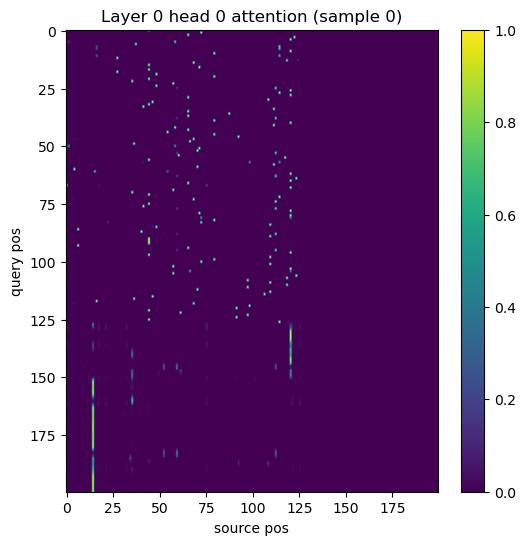


Top 6 tokens attended by query pos 126:
 1. pos=114 token='at' score=1.0000
 2. pos=108 token='actors' score=0.0000
 3. pos=86 token='filmed' score=0.0000
 4. pos=16 token='scenery' score=0.0000
 5. pos=51 token='scenery' score=0.0000
 6. pos= 5 token='venezuelan' score=0.0000


In [65]:

# Capture & visualize per-layer self-attention 


if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

xb, yb = next(iter(test_loader))
xb = xb.to(device)
pad_mask = (xb == pad_idx)          
# initial embeddings + pos
h = model.emb(xb) * math.sqrt(model.emb.embedding_dim)
h = model.pos(h)                    

attn_store = []
for layer in model.encoder.layers:
    # call self_attn with need_weights=True and average_attn_weights=False to get per-head weights
    attn_out, attn_w = layer.self_attn(h, h, h, key_padding_mask=pad_mask, need_weights=True, average_attn_weights=False)
    # attn_w shape -> (B * num_heads, T, S) ; reshape -> (B, H, T, S)
    B = xb.size(0)
    H = layer.self_attn.num_heads
    T = h.size(1)
    attn_w = attn_w.view(B, H, T, T).detach().cpu()
    attn_store.append(attn_w)

    # replicate remainder of TransformerEncoderLayer forward to get input for next layer
    h2 = layer.dropout1(attn_out)
    h = layer.norm1(h + h2)
    ff = layer.linear2(layer.dropout(layer.activation(layer.linear1(h))))
    h = layer.norm2(h + layer.dropout2(ff))

# inspect shapes
print("Captured attention shapes per layer (B, H, T, S):")
for i, A in enumerate(attn_store):
    print(f" layer {i}: {A.shape}")

# plot layer 0, sample 0, head 0 (adjust indices)
layer_idx, sample_idx, head_idx = 0, 0, 0
A = attn_store[layer_idx].numpy()    # (B, H, T, S)
mat = A[sample_idx, head_idx]        # (T, S)

plt.figure(figsize=(6,6))
plt.imshow(mat, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title(f"Layer {layer_idx} head {head_idx} attention (sample {sample_idx})")
plt.xlabel("source pos"); plt.ylabel("query pos")
plt.show()

# print top-k tokens for a chosen query pos 
seq_ids = xb[sample_idx].cpu().numpy()
nonpad = np.where(seq_ids != pad_idx)[0]
query_pos = nonpad[-1] if len(nonpad) else 0
scores = mat[query_pos]
topk = 6
idxs = np.argsort(-scores)[:topk]
tokens = [itos[int(i)] for i in seq_ids[:mat.shape[1]]]
print(f"\nTop {topk} tokens attended by query pos {query_pos}:")
for rank, src in enumerate(idxs, 1):
    print(f" {rank}. pos={src:2d} token={tokens[src]!r} score={scores[src]:.4f}")

inspect the exact token and its surrounding context for the position currently being analyzed in the attention map.

In [66]:

# show token at query_pos and nearby context (requires xb, sample_idx, query_pos, itos exist)
seq_ids = xb[sample_idx].cpu().numpy()
S = seq_ids.shape[0]
if query_pos >= S:
    print(f"query_pos {query_pos} out of range (seq length {S})")
else:
    token_at_q = itos[int(seq_ids[query_pos])]
    print(f"query_pos={query_pos} token={token_at_q!r}\n")

    # print a window of tokens around query_pos
    L = 10
    start = max(0, query_pos - L)
    end = min(S, query_pos + L + 1)
    print("context (pos: token):")
    for p in range(start, end):
        tok = itos[int(seq_ids[p])]
        marker = "  <-- query" if p == query_pos else ""
        print(f" {p:3d}: {tok!r}{marker}")

    # optional reconstruct small text span
    span = " ".join(itos[int(i)] for i in seq_ids[start:end])
    print("\nreconstructed span:", span)


query_pos=126 token='dvd'

context (pos: token):
 116: 'one'
 117: 'bad'
 118: 'film'
 119: "don't"
 120: 'waste'
 121: 'the'
 122: '5'
 123: '00'
 124: 'on'
 125: 'the'
 126: 'dvd'  <-- query
 127: '<pad>'
 128: '<pad>'
 129: '<pad>'
 130: '<pad>'
 131: '<pad>'
 132: '<pad>'
 133: '<pad>'
 134: '<pad>'
 135: '<pad>'
 136: '<pad>'

reconstructed span: one bad film don't waste the 5 00 on the dvd <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>


visualizes the attention map for the first layer and head of the Transformer model.

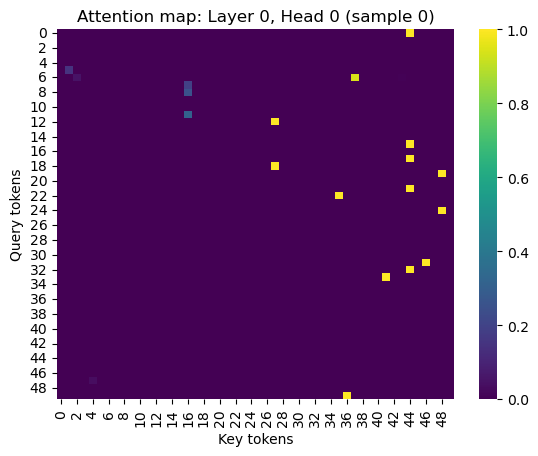

In [67]:


sample_idx = 0  

if 'attn_store' not in globals() or len(attn_store) == 0:
    raise RuntimeError("attn_store is empty — run the attention capture cell first")

A = attn_store[0]  # first layer
# handle both shapes returned by different PyTorch versions
if A.dim() == 4:
    # (B, H, T, S)
    attn = A[sample_idx, 0].cpu().detach().numpy()   # first head
elif A.dim() == 3:
    # (B, T, S) averaged heads
    attn = A[sample_idx].cpu().detach().numpy()
else:
    raise RuntimeError(f"unexpected attention tensor dim: {A.dim()}")

sns.heatmap(attn[:50, :50], cmap="viridis")
plt.title(f"Attention map: Layer 0, Head 0 (sample {sample_idx})")
plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.show()


zoom in on how one specific token (at query_pos) attends to others in the sequence. prints the first 50 tokens in review

Tokens positions 1..50:
  1: id=  18 token='movie'
  2: id=   7 token='is'
  3: id=  81 token='great'
  4: id=  16 token='for'
  5: id=8827 token='venezuelan'
  6: id=17019 token='tourism'
  7: id=6237 token='birds'
  8: id=6237 token='birds'
  9: id=   4 token='and'
 10: id=  52 token='more'
 11: id=6237 token='birds'
 12: id=  62 token='only'
 13: id= 301 token='1'
 14: id=11799 token='piranha'
 15: id= 315 token='nice'
 16: id=1512 token='scenery'
 17: id=   2 token='the'
 18: id=  62 token='only'
 19: id=2406 token='highlight'
 20: id=  14 token='was'
 21: id=   2 token='the'
 22: id=7633 token='alligator'
 23: id= 110 token='seen'
 24: id= 304 token='during'
 25: id=   3 token='a'
 26: id=  53 token='very'
 27: id= 211 token='long'
 28: id=   4 token='and'
 29: id= 354 token='boring'
 30: id=5862 token='motorcycle'
 31: id=1233 token='race'
 32: id=   2 token='the'
 33: id= 136 token='end'
 34: id=  51 token='when'
 35: id=14005 token='caribe'
 36: id=13148 token='drowns'
 37: id=

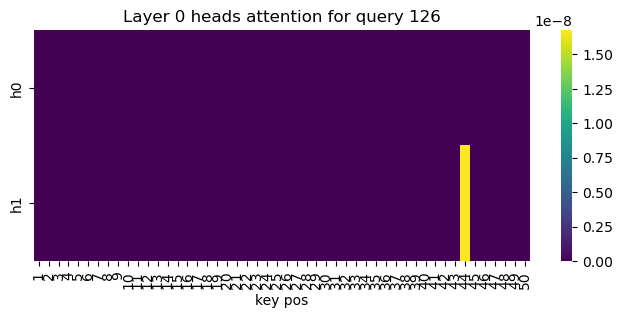


Layer 1 attention (sample 0)
 head 0 keys 1..50: [0.0185 0.0085 0.0097 0.0025 0.0164 0.004  0.0044 0.0045 0.0023 0.0079
 0.0045 0.0065 0.0033 0.0085 0.0038 0.0072 0.0095 0.0063 0.0101 0.0045
 0.0096 0.0131 0.0033 0.0108 0.0043 0.0047 0.0115 0.0023 0.015  0.0076
 0.0027 0.0098 0.0067 0.0083 0.0202 0.0028 0.0082 0.0043 0.0033 0.0048
 0.005  0.0023 0.0084 0.0057 0.0035 0.018  0.0175 0.0041 0.0053 0.0209]
 head 1 keys 1..50: [0.0082 0.0116 0.0232 0.0038 0.015  0.007  0.0046 0.0046 0.0068 0.0048
 0.0045 0.0103 0.0048 0.0091 0.0102 0.0031 0.0139 0.0104 0.0062 0.0071
 0.014  0.0063 0.0071 0.0061 0.0045 0.0031 0.0062 0.0067 0.004  0.0055
 0.005  0.0139 0.0041 0.0119 0.0046 0.004  0.012  0.0046 0.0061 0.0028
 0.0167 0.0049 0.0117 0.0056 0.0064 0.013  0.0101 0.0066 0.0047 0.0099]
 avg heads: [0.0134 0.0101 0.0165 0.0031 0.0157 0.0055 0.0045 0.0045 0.0046 0.0064
 0.0045 0.0084 0.0041 0.0088 0.007  0.0051 0.0117 0.0084 0.0082 0.0058
 0.0118 0.0097 0.0052 0.0085 0.0044 0.0039 0.0089 0.0045 0.0095 

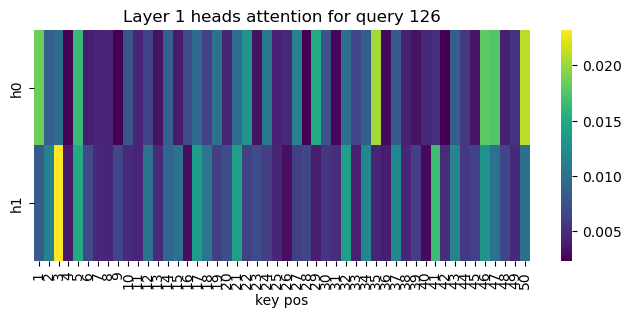

In [68]:
# Show tokens 1-50 and attention over keys 1-50 for a sample

# Config (adjust as needed)
sample_idx = 0        # which batch item to inspect
query_pos = 126       # which query position to inspect
show_range = 50       # show tokens/keys 1..show_range


assert 'xb' in globals(), "xb (batch tensor) not found — run the data loader cell to get a batch"
seq_ids = xb[sample_idx].cpu().numpy()
seq_len = seq_ids.shape[0]
end = min(show_range, seq_len-1)

print(f"Tokens positions 1..{end}:")
for pos in range(1, end+1):
    tok = itos[int(seq_ids[pos])]
    print(f"{pos:3d}: id={int(seq_ids[pos]):4d} token={tok!r}")

if 'attn_store' in globals() and len(attn_store) > 0:
    for layer_idx, A in enumerate(attn_store):
        print(f"\nLayer {layer_idx} attention (sample {sample_idx})")
        # A can be (B,H,T,S) or (B,T,S)
        if A.dim() == 4:
            _, H, T, S = A.shape
            # clip S to seq_len if necessary
            S = min(S, seq_len)
            # show per-head attention vector for query_pos over keys 1..end
            for h in range(H):
                vec = A[sample_idx, h, query_pos, 1:end+1].cpu().numpy()
                print(f" head {h} keys 1..{end}: {np.round(vec, 4)}")
            # averaged heads
            avg = A[sample_idx].mean(axis=0)  # (T,S)
            avg_vec = avg[query_pos, 1:end+1]
            print(" avg heads:", np.round(avg_vec.cpu().numpy(), 4))
            # plot heatmap (heads x keys)
            heat = np.stack([A[sample_idx, h, query_pos, 1:end+1].cpu().numpy() for h in range(H)], axis=0)
            plt.figure(figsize=(8, 2+H*0.5))
            sns.heatmap(heat, xticklabels=range(1, end+1), yticklabels=[f"h{h}" for h in range(H)], cmap="viridis")
            plt.xlabel("key pos"); plt.title(f"Layer {layer_idx} heads attention for query {query_pos}")
            plt.show()
        elif A.dim() == 3:
            # (B, T, S) averaged already
            vec = A[sample_idx, query_pos, 1:end+1].cpu().numpy()
            print(" avg-attn keys 1..end:", np.round(vec, 4))
            plt.figure(figsize=(8,2))
            plt.bar(np.arange(1, end+1), vec)
            plt.xlabel("key pos"); plt.title(f"Layer {layer_idx} avg attention for query {query_pos}")
            plt.show()
        else:
            print("Unexpected attn tensor shape:", A.shape)
else:
    print("\nNo attn_store found. Run the attention capture cell first (the cell that calls layer.self_attn with need_weights=True).")

In [69]:

print(f"Finished in {time.time()-start:.1f}s. Best test acc: {best_acc:.4f}")

# Save best model and vocab 
if best_state is not None:
    torch.save({"model_state_dict": best_state, "config": {
        "vocab_size": vocab_size, "pad_idx": pad_idx, "max_len": MAX_LEN, "d_model": 128
    }}, MODEL_PATH)
    with open(VOCAB_PATH, "w", encoding="utf-8") as f:
        json.dump({"itos": itos, "stoi": stoi}, f, ensure_ascii=False)
    print(f"Saved model to {MODEL_PATH} and vocab to {VOCAB_PATH}")


Finished in 1761101080.8s. Best test acc: 0.7420
Saved model to mini_transformer_imdb.pt and vocab to mini_transformer_imdb_vocab.json


In [70]:
# check number of encoder layers and heads
print("num encoder layers:", len(model.encoder.layers))
for i, layer in enumerate(model.encoder.layers):
    print(f"layer {i} n_heads:", layer.self_attn.num_heads)

num encoder layers: 2
layer 0 n_heads: 2
layer 1 n_heads: 2
